# PCMCI + ParCorr — All Crops, Monthly

Two-phase analysis:

1. **Climate-only** (`climate`, 10 vars) — run once per crop, no RV. Recovers the inter-variable causal structure within climate alone. Climate variables differ by crop growing region (prcp, awnd, tmin, tmax, pdsi are region-specific), so each crop gets its own climate graph.

2. **Per-crop RV analysis** (`climate_rv`, `macro_news_climate_rv`) — run per crop with crop-specific `weekly_rv`. Tests whether climate and macro/news variables Granger-cause each crop's realized volatility.

Preprocessing identical to `eda_preprocessing.ipynb`: interpolate → ffill → Gaussian detrend (15-yr) → anomalize → `pp.trafo2normal`.

## 0. Imports & Configuration

In [19]:
import sys
from pathlib import Path

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ─────────────────────────────────────────────────────────────
CROPS     = ['corn', 'soybean', 'wheat']
FREQUENCY = 'monthly'

CYCLE_LEN    = 12                   # months per year
SMOOTH_WIDTH = 15 * CYCLE_LEN       # 15-year Gaussian detrend window
TAU_MAX      = 3                    # from eda_preprocessing.ipynb analysis

print(f'Crops     : {CROPS}')
print(f'Frequency : {FREQUENCY}')
print(f'tau_max   : {TAU_MAX}')
print(f'cycle_len : {CYCLE_LEN}')

Crops     : ['corn', 'soybean', 'wheat']
Frequency : monthly
tau_max   : 3
cycle_len : 12


## 1. Feature Group Definitions

| Group | Variables | N |
|-------|-----------|---|
| `rv` | `weekly_rv` | 1 |
| `climate` | `prcp`, `awnd`, `tmin`, `tmax`, `co2`, `pdsi`, `EVAP`, `soil_moisture_mean_m3m3`, `cloud_cover_mean_pct`, `humidity_mean_pct` | 10 |
| `macro` | `DJIA_Index`, `WTI_Index`, `Broad_Dollar_index`, `Stock_Uncertainty` | 4 |
| `news` | `frbsf_sentiment`, `epu_index`, `Text_Climate_Anomaly` | 3 |

**Phase 1 — climate-only (run per crop, no RV):**

| Feature Set | Groups | N | Why run separately |
|-------------|--------|---|--------------------|
| `climate` | climate | 10 | Climate causal structure is independent of RV; isolates physical chains before adding the financial target |

**Phase 2 — per-crop RV analysis:**

| Feature Set | Groups | N | Purpose |
|-------------|--------|---|---------|
| `climate_rv` | climate + rv | 11 | Tests climate → RV Granger-causality after conditioning on RV's own past |
| `macro_news_climate_rv` | macro + news + climate + rv | 18 | Full model; tests whether macro/news mediate or suppress climate → RV links |

In [20]:
FEATURE_GROUPS = {
    'rv'     : ['weekly_rv'],
    'climate': ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct'],
    'macro'  : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'   : ['frbsf_sentiment', 'epu_index', 'Text_Climate_Anomaly'],
}

GROUP_COLORS = {
    'rv': '#e41a1c', 'climate': '#377eb8', 'macro': '#4daf4a', 'news': '#984ea3',
}

FEATURE_SETS = {
    'climate'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

def build_cols(groups: list[str]) -> list[str]:
    cols: list[str] = []
    for g in groups:
        cols.extend(FEATURE_GROUPS[g])
    return cols

def group_of(col: str) -> str:
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

for name, groups in FEATURE_SETS.items():
    print(f'{name:30s}: {len(build_cols(groups)):2d} vars')

climate                       : 10 vars
climate_rv                    : 11 vars
macro_news_climate_rv         : 18 vars


## 2. Preprocessing & PCMCI Helper Functions

Preprocessing pipeline (identical to `eda_preprocessing.ipynb`):

| Step | Method | Why |
|------|--------|-----|
| Impute | Interpolate `pdsi`/`Broad_Dollar_index`, ffill `DJIA_Index` | Fill isolated gaps before detrending |
| Detrend | `pp.smooth(residuals=True, kernel='gaussian', smooth_width=15yr)` | CO₂/DJIA/Broad Dollar have 10–35% secular drift — removes spurious common-driver links |
| Anomalize | Subtract phase mean, divide by phase std | Annual cycles in temp/precip/EVAP inflate cross-group correlations |
| Gaussianise | `pp.trafo2normal` | 15/18 features non-Gaussian (SW p<0.05); ParCorr t-test null requires Gaussian marginals |

In [21]:
def load_and_preprocess(crop: str, frequency: str) -> tuple[np.ndarray, list[str], pd.Series]:
    """Load CSV, impute, detrend, anomalize, Gaussianise. Returns (arr_normal, col_names, dates)."""
    path = ROOT / 'data' / frequency / f'{crop}.csv'
    raw  = pd.read_csv(path, parse_dates=['date'])
    df   = raw.sort_values('date').reset_index(drop=True)

    # Impute
    for col in ['pdsi', 'Broad_Dollar_index']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
    for col in ['DJIA_Index']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    col_names = [c for c in df.columns if c != 'date']
    arr = df[col_names].values.astype(float)

    # Detrend (15-year Gaussian smoother)
    cycle_len    = 52 if frequency == 'weekly' else 12
    smooth_width = 15 * cycle_len
    arr_detrended = pp.smooth(arr, smooth_width=smooth_width, kernel='gaussian', residuals=True)

    # Anomalize
    arr_anom = arr_detrended.copy().astype(float)
    for phase in range(cycle_len):
        idx = slice(phase, None, cycle_len)
        arr_anom[idx] -= arr_detrended[idx].mean(axis=0)
        std = arr_detrended[idx].std(axis=0)
        std[std == 0] = 1.0
        arr_anom[idx] /= std

    # Gaussianise
    arr_normal = pp.trafo2normal(arr_anom)

    return arr_normal, col_names, df['date']


def run_parcorr(
    feature_set_name: str,
    col_names: list[str],
    arr_preprocessed: np.ndarray,
    all_cols: list[str],
    tau_max: int,
    pc_alpha: float = 0.2,
    alpha_level: float = 0.05,
    fdr_method: str = 'fdr_bh',
    max_conds_dim: int | None = None,
    verbosity: int = 0,
) -> dict:
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]

    dataframe = pp.DataFrame(
        data_subset,
        var_names=col_names,
        datatime={0: np.arange(len(data_subset))},
    )
    parcorr = ParCorr(significance='analytic')
    pcmci   = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=verbosity)

    results = pcmci.run_pcmci(
        tau_min=1, tau_max=tau_max,
        pc_alpha=pc_alpha, alpha_level=alpha_level,
        fdr_method=fdr_method, max_conds_dim=max_conds_dim,
    )
    q_matrix = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method=fdr_method,
    )
    graph = pcmci.get_graph_from_pmatrix(
        p_matrix=q_matrix, alpha_level=alpha_level, tau_min=1, tau_max=tau_max,
    )
    results.update({
        'graph': graph, 'q_matrix': q_matrix,
        'pcmci': pcmci, 'col_names': col_names,
    })
    return results


def plot_results(results: dict, title: str, tau_max: int) -> None:
    col_names = results['col_names']
    n = len(col_names)

    tp.plot_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names,
        link_colorbar_label='cross-MCI (ParCorr)', node_colorbar_label='auto-MCI',
        show_autodependency_lags=True,
        figsize=(max(8, n * 0.6), max(6, n * 0.5)),
    )
    plt.suptitle(f'{title}\ntau_max={tau_max} | FDR-BH α=0.05',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    tp.plot_time_series_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names, link_colorbar_label='MCI',
        figsize=(max(12, n * 0.8), 6),
    )
    plt.suptitle(f'{title} — time-series graph',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


def extract_rv_links(results: dict, alpha: float = 0.05) -> pd.DataFrame:
    col_names = results['col_names']
    if 'weekly_rv' not in col_names:
        return pd.DataFrame()
    rv_idx  = col_names.index('weekly_rv')
    q_mat   = results['q_matrix']
    val_mat = results['val_matrix']
    rows = [
        {'cause': col_names[j], 'lag': tau, 'val': val_mat[j, rv_idx, tau],
         'q_val': q_mat[j, rv_idx, tau]}
        for j in range(len(col_names))
        for tau in range(1, q_mat.shape[2])
        if q_mat[j, rv_idx, tau] < alpha
    ]
    return pd.DataFrame(rows)


print('Helper functions defined.')

Helper functions defined.


## 3. PCMCI + ParCorr — Parameter Suggestions for All Feature Sets

| Feature Set | N | tau_max | pc_alpha | alpha_level | fdr_method | max_conds_dim | Notes |
|-------------|---|---------|----------|-------------|------------|---------------|-------|
| `climate` | 10 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Climate-only causal chain |
| `climate_rv` | 11 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Tests climate→RV Granger-causality |
| `macro_rv` | 5 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Baseline financial model |
| `macro_news_rv` | 8 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Adds news sentiment channel |
| `macro_news_climate_rv` | 18 | 3 | 0.2 | 0.05 | `fdr_bh` | `None` | Full model; matches EDA defaults |

**Rationale:**
- **`tau_max=6`**: Monthly RV auto-bivCI decays below 95% significance at lag ~4; lag 3 adds buffer for slower climate signals (matches `eda_preprocessing.ipynb` Section 12).
- **`pc_alpha=0.2`**: Liberal PC skeleton to preserve MCI step power; final FDR at 0.05 controls false links.
- **`max_conds_dim=None`**: Matches EDA sanity-check default. PC step's own pruning controls conditioning-set size; capping would suppress cross-group links.
- **`significance='analytic'`**: Valid after `trafo2normal`; no permutation cost.

## 4. Phase 1 — Climate-Only Causal Graphs (per crop, no RV)

Runs the `climate` feature set for each crop independently.  
Climate variables differ by growing region, so each crop produces its own causal graph.  
RV is intentionally excluded here to study the climate system in isolation.


  Phase 1 | CLIMATE | CORN

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00009 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.569
        (prcp -1): pval = 0.00000 | val =  0.460

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.00529 | val =  0.348

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.554

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):


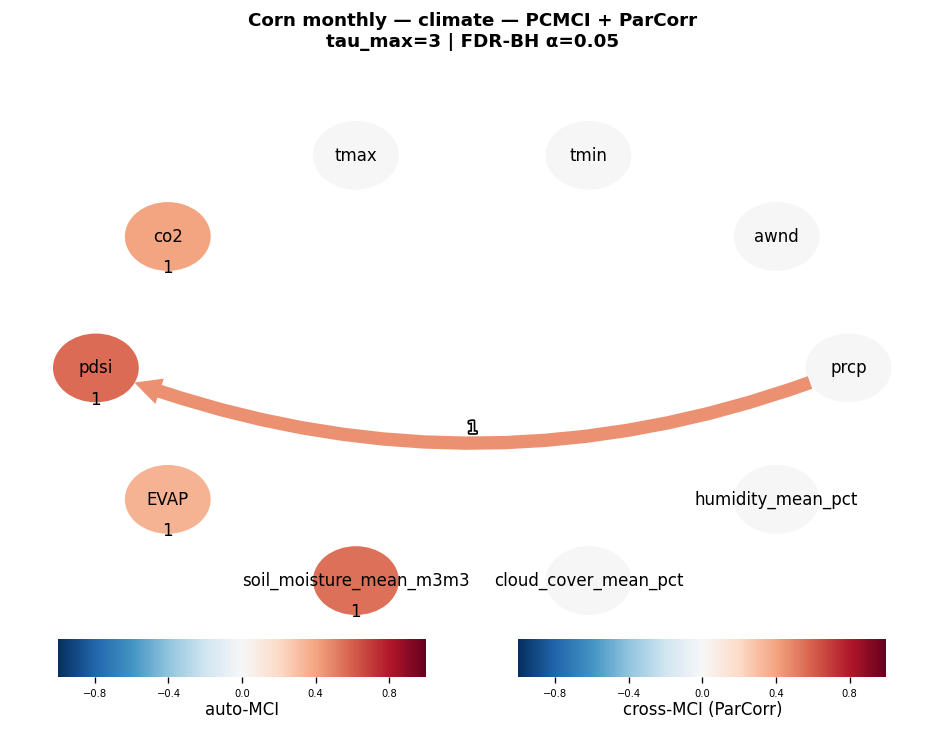

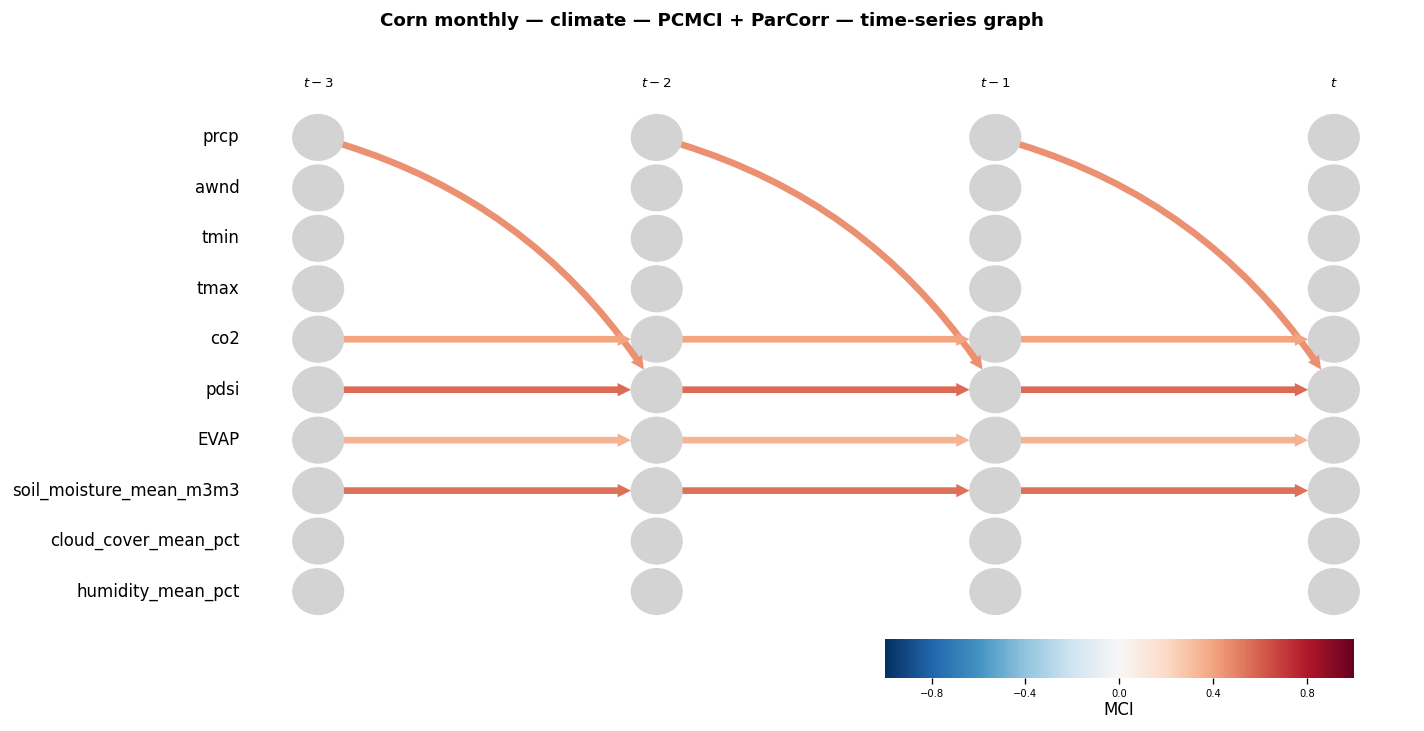


  Phase 1 | CLIMATE | SOYBEAN

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00001 | val =  0.427

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.561
        (prcp -1): pval = 0.00001 | val =  0.439

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.01348 | val =  0.337

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.493

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):


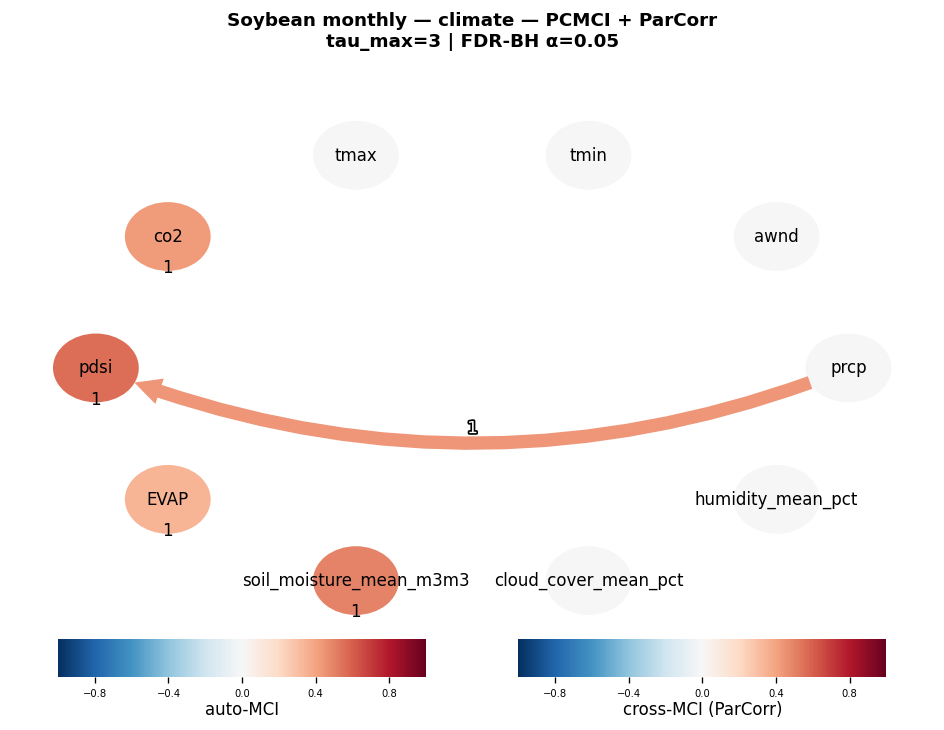

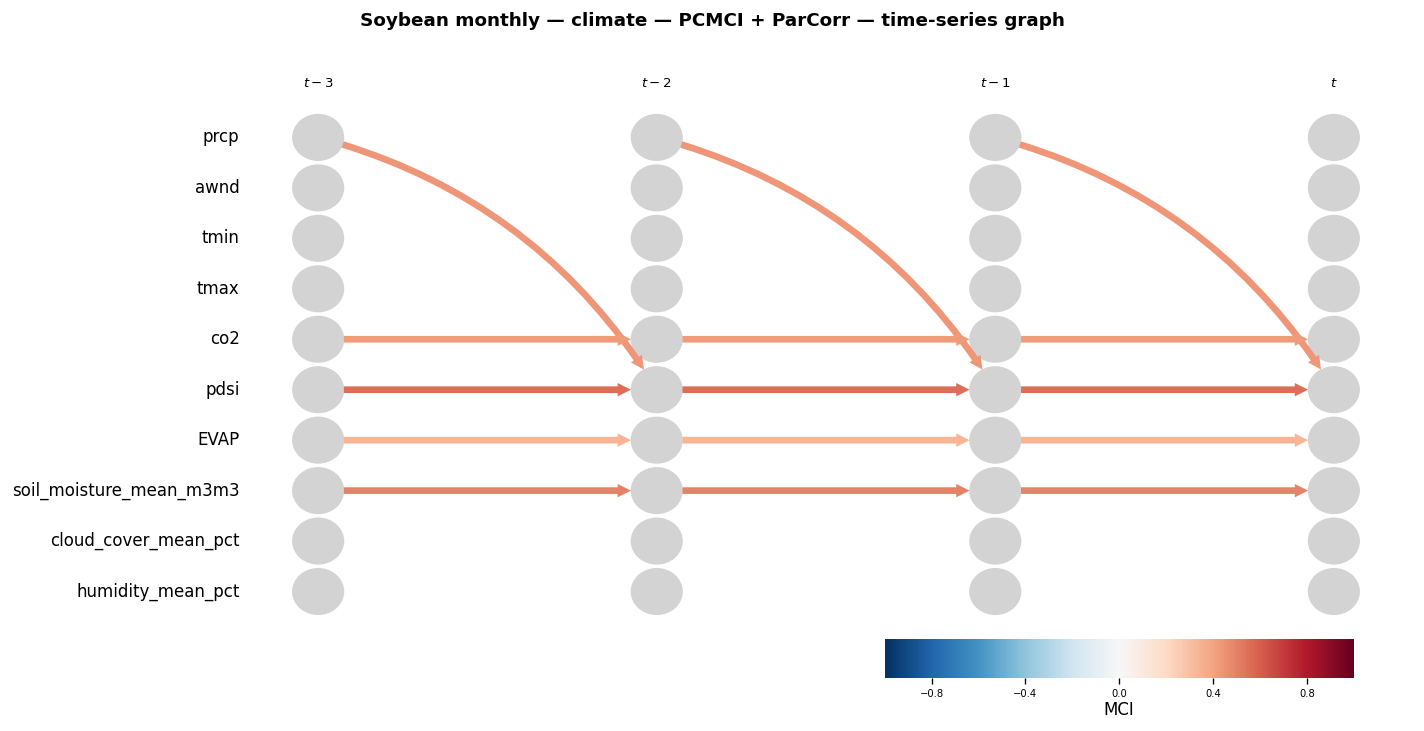


  Phase 1 | CLIMATE | WHEAT

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00037 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00088 | val =  0.389
        (prcp -1): pval = 0.00261 | val =  0.361

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.00165 | val =  0.369

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.554

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.01528 | val =  0.329


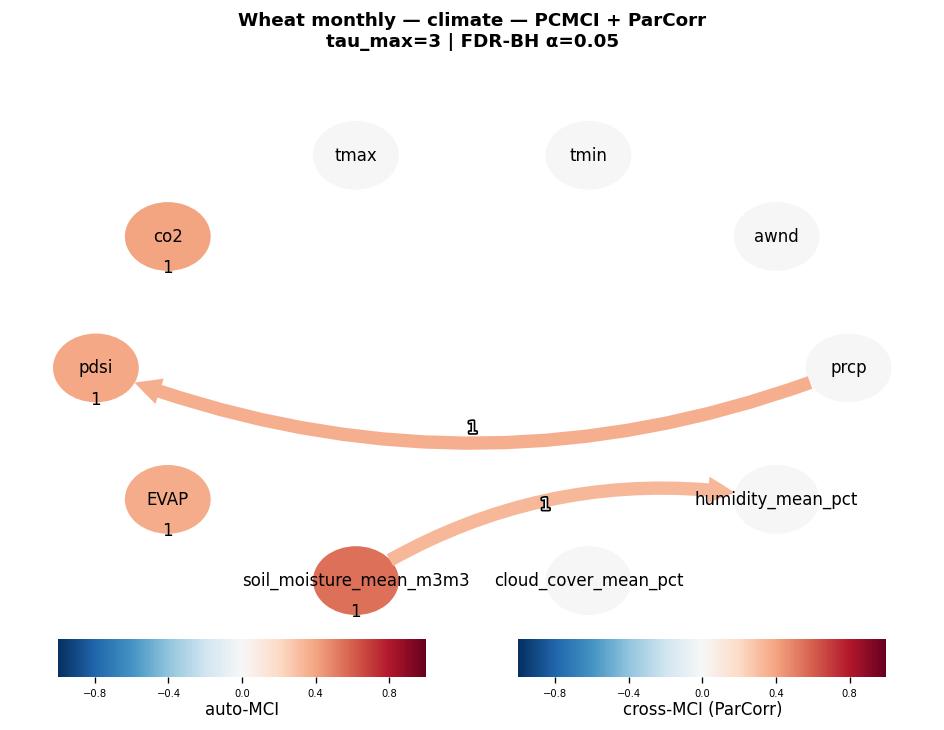

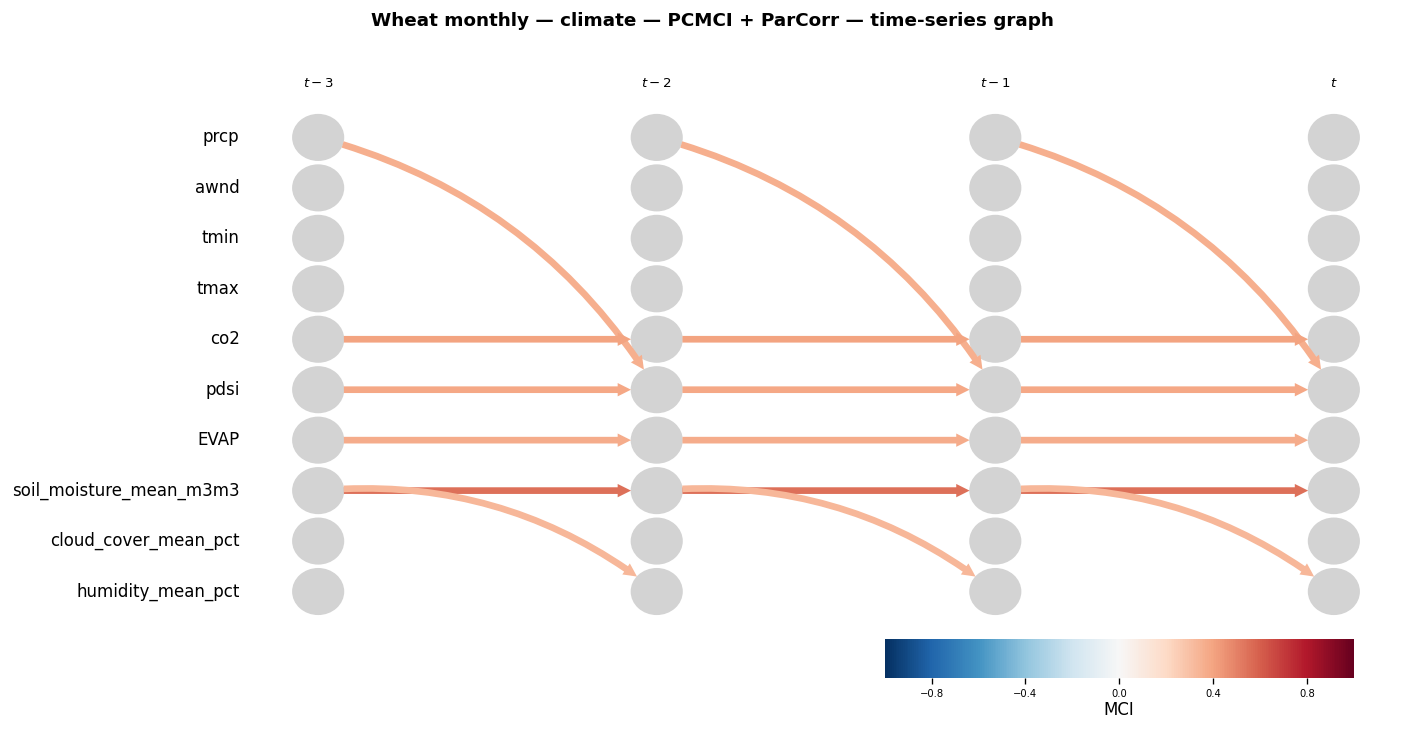


Phase 1 done.


In [22]:
# Phase 1: climate-only — run once per crop (no RV)
climate_results: dict[str, dict] = {}

climate_cols = build_cols(['climate'])

for crop in CROPS:
    print(f'\n{"="*60}')
    print(f'  Phase 1 | CLIMATE | {crop.upper()}')
    print(f'{"="*60}')

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    cols = [c for c in climate_cols if c in all_cols]

    res = run_parcorr(
        feature_set_name='climate',
        col_names=cols,
        arr_preprocessed=arr_normal,
        all_cols=all_cols,
        tau_max=TAU_MAX,
        pc_alpha=0.2,
        alpha_level=0.05,
        fdr_method='fdr_bh',
        max_conds_dim=None,
        verbosity=0,
    )
    climate_results[crop] = res

    res['pcmci'].print_significant_links(
        p_matrix=res['q_matrix'],
        val_matrix=res['val_matrix'],
        alpha_level=0.05,
    )
    plot_results(
        res,
        title=f'{crop.capitalize()} {FREQUENCY} — climate — PCMCI + ParCorr',
        tau_max=TAU_MAX,
    )

print('\nPhase 1 done.')

## 5. Phase 2 — Per-Crop RV Analysis (climate_rv and macro_news_climate_rv)

Runs `climate_rv` and `macro_news_climate_rv` for each crop.  
Only `weekly_rv` is crop-specific; all other variables are shared.  
The key question: do climate (and macro/news) variables Granger-cause each crop's realized volatility?


######################################################################
  Phase 2 | CORN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 18)  (2009-04-01 → 2025-03-01)

  ── climate_rv (11 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00009 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.569
        (prcp -1): pval = 0.00000 | val =  0.454

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.00538 | val =  0.348

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.554

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable weekly_rv has 1 link(s):
      

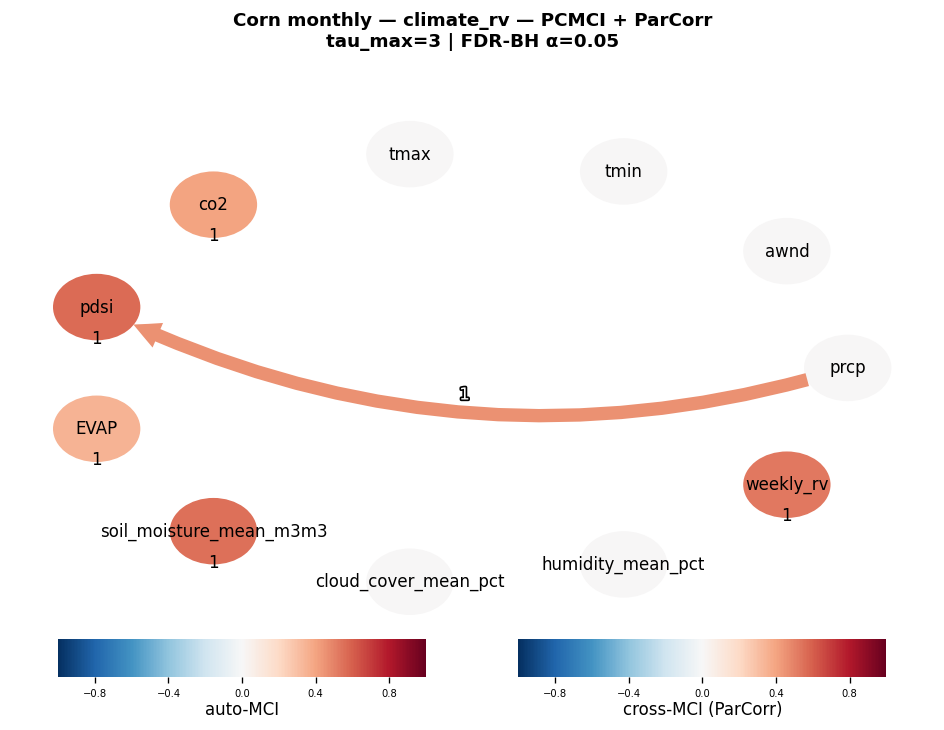

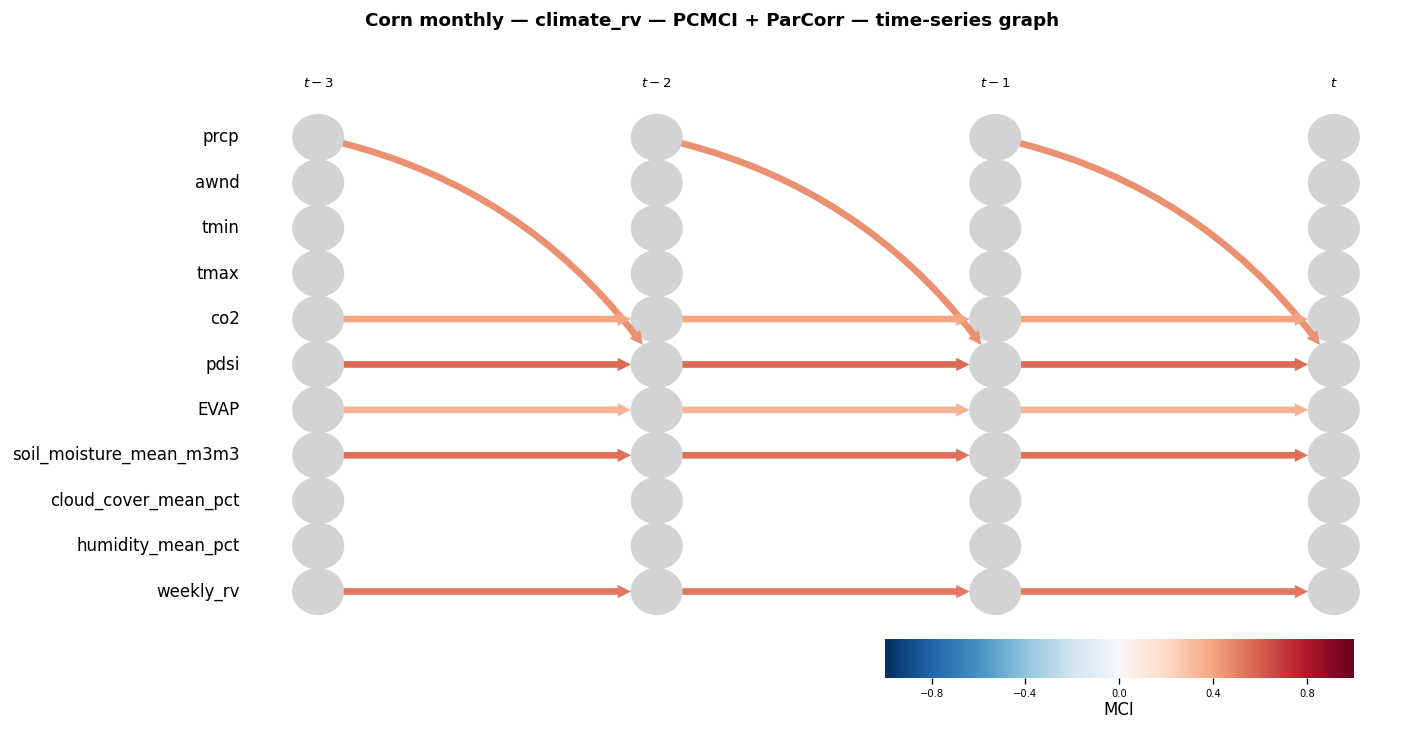


  ── macro_news_climate_rv (18 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 2 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656
        (co2 -3): pval = 0.04345 | val =  0.321

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.712

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.750

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.492

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.651
        (Stock_Uncertainty -1): pval = 0.00964 | val = -0.350

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00000 | val =  0.461

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00000 | val =  0.480

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin ha

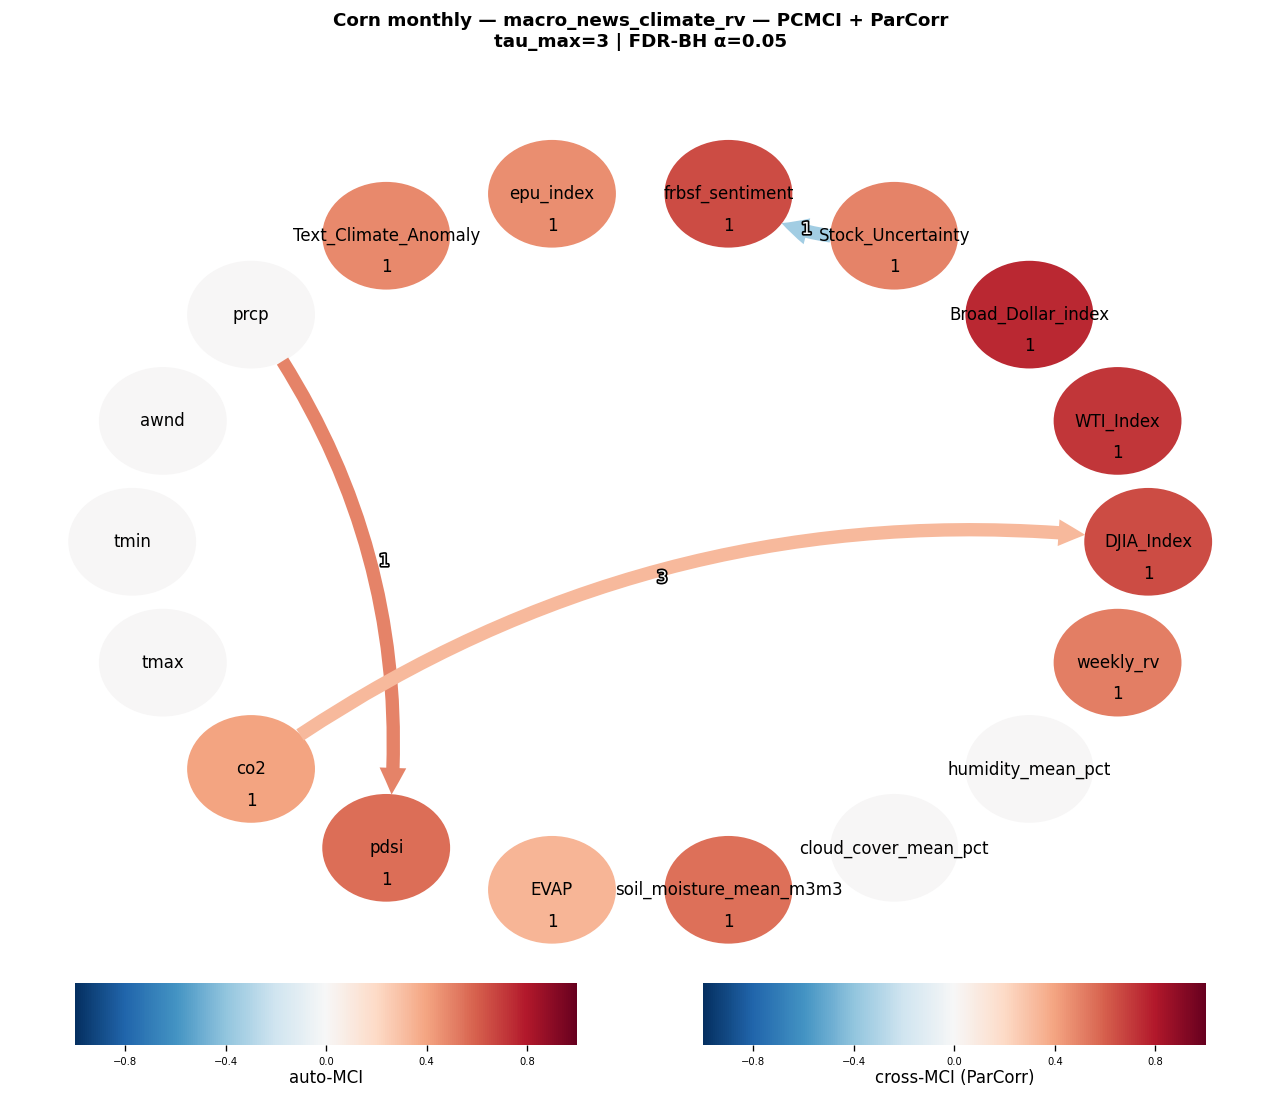

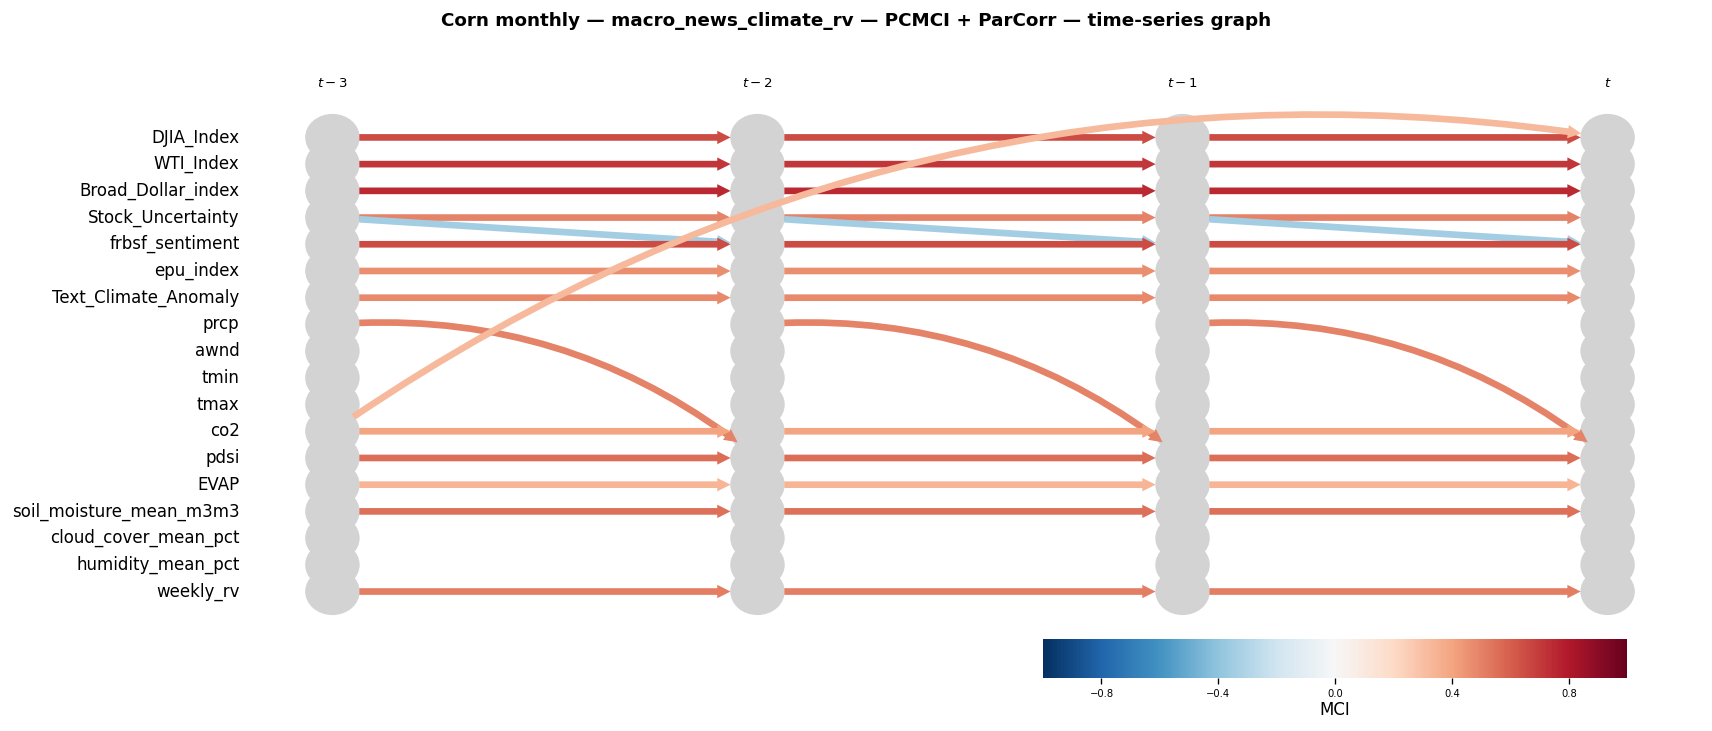


######################################################################
  Phase 2 | SOYBEAN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 18)  (2009-04-01 → 2025-03-01)

  ── climate_rv (11 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00001 | val =  0.427

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.561
        (prcp -1): pval = 0.00001 | val =  0.439

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.01371 | val =  0.337

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.493

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable weekly_rv has 1 link(s):
   

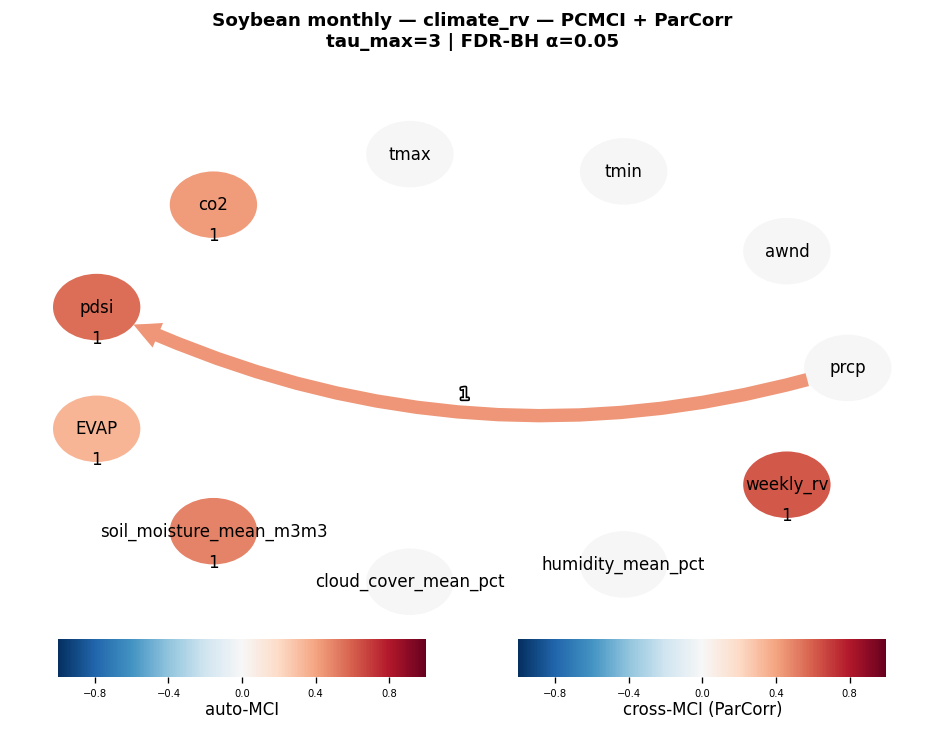

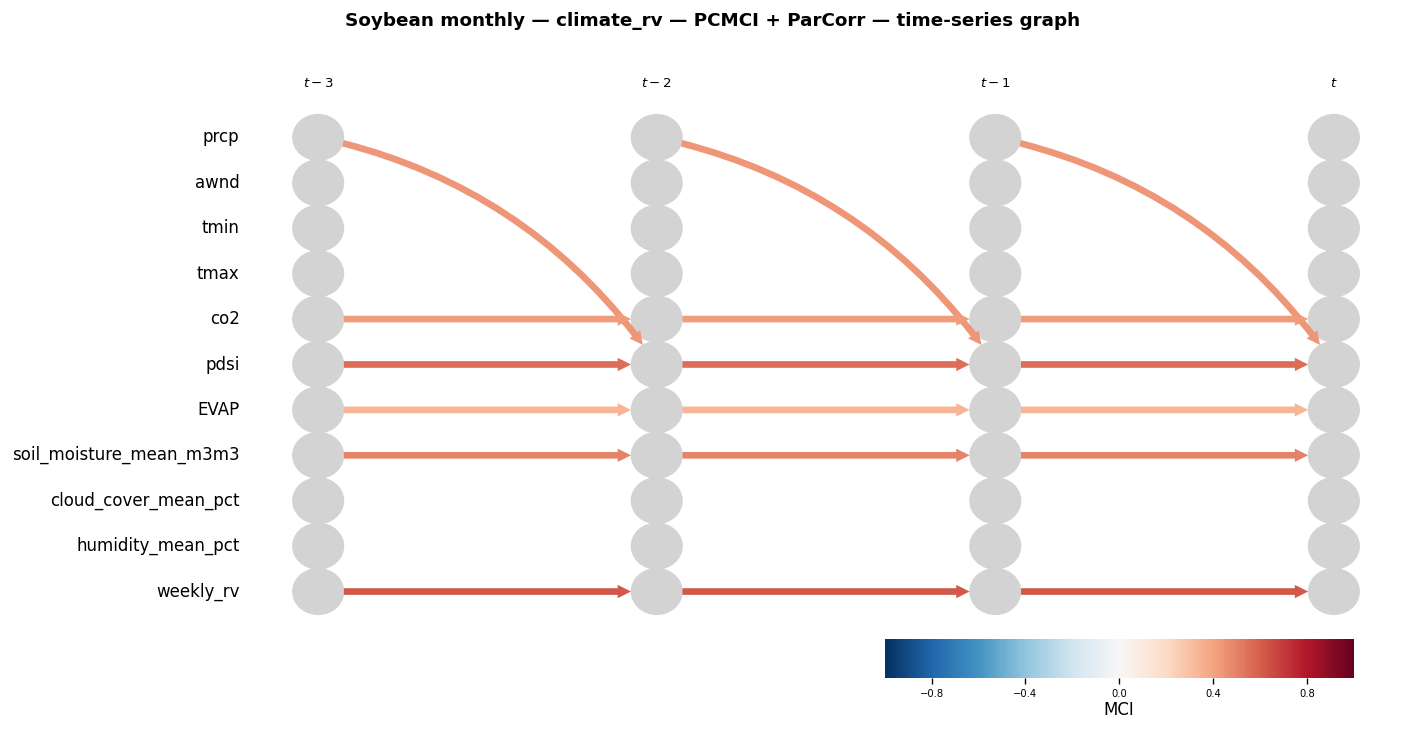


  ── macro_news_climate_rv (18 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.715

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.750

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.491

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.651
        (Stock_Uncertainty -1): pval = 0.00969 | val = -0.350

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00000 | val =  0.468

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00000 | val =  0.480

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):



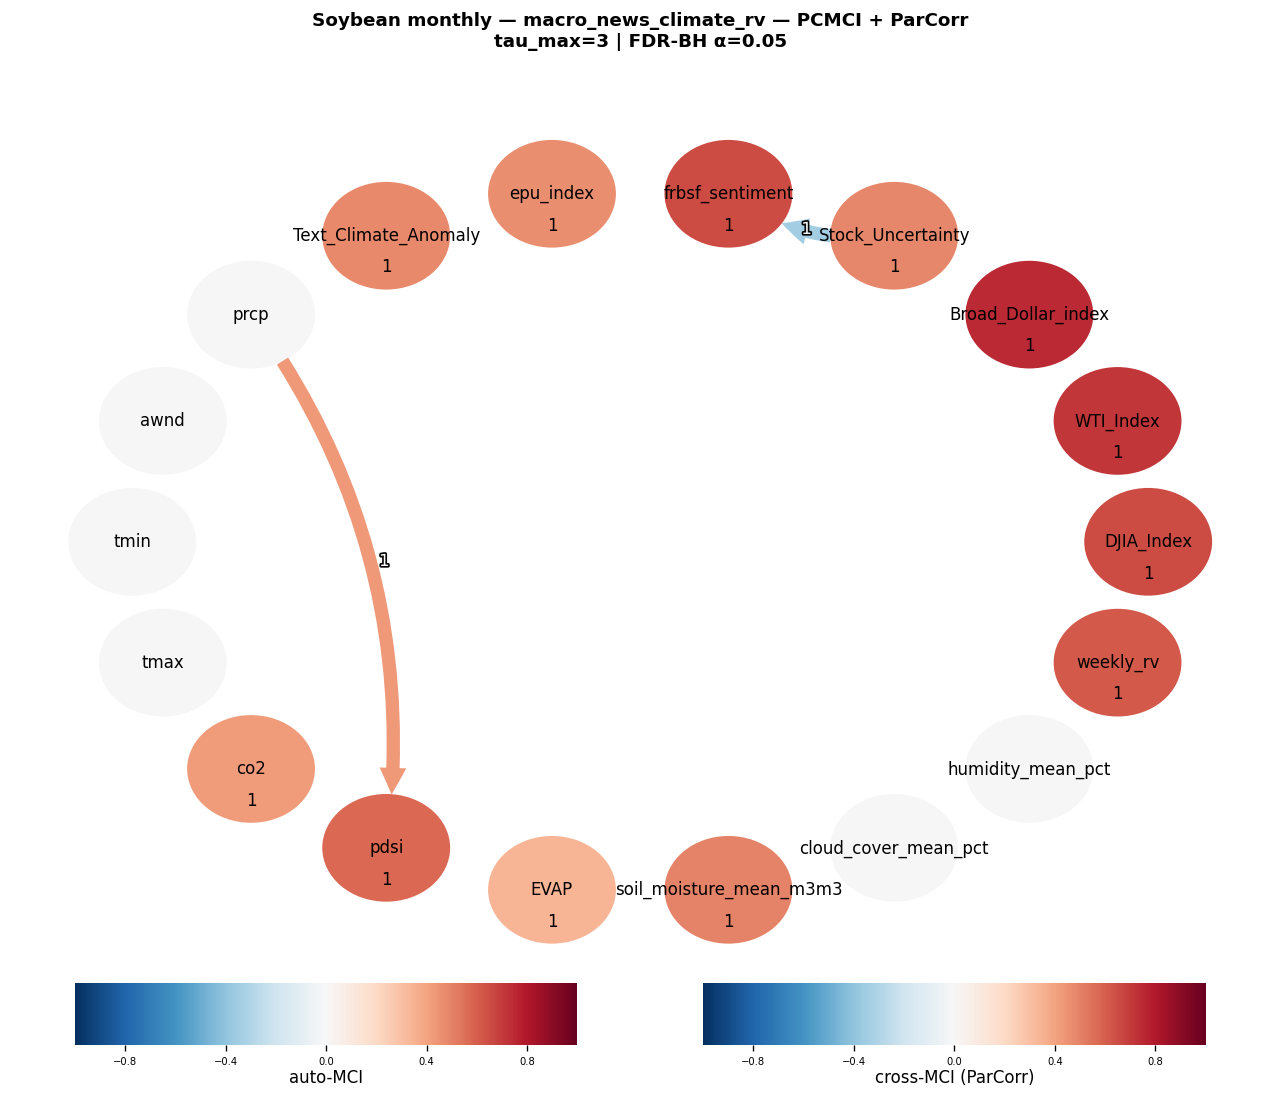

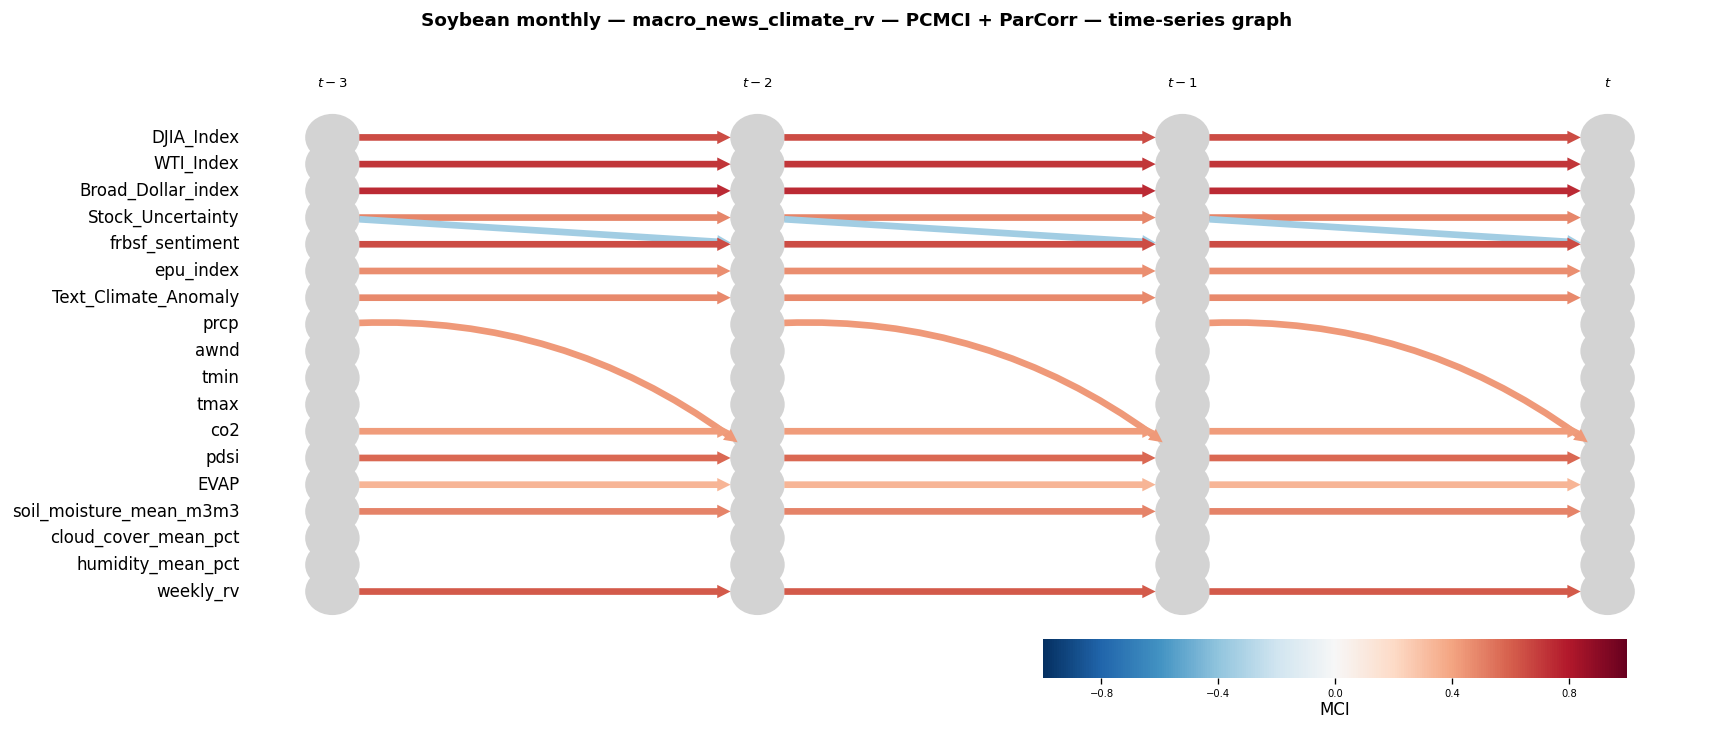


######################################################################
  Phase 2 | WHEAT  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 18)  (2009-04-01 → 2025-03-01)

  ── climate_rv (11 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -1): pval = 0.00024 | val =  0.402

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00073 | val =  0.389
        (prcp -1): pval = 0.00265 | val =  0.361

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.00154 | val =  0.369

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.554

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval =

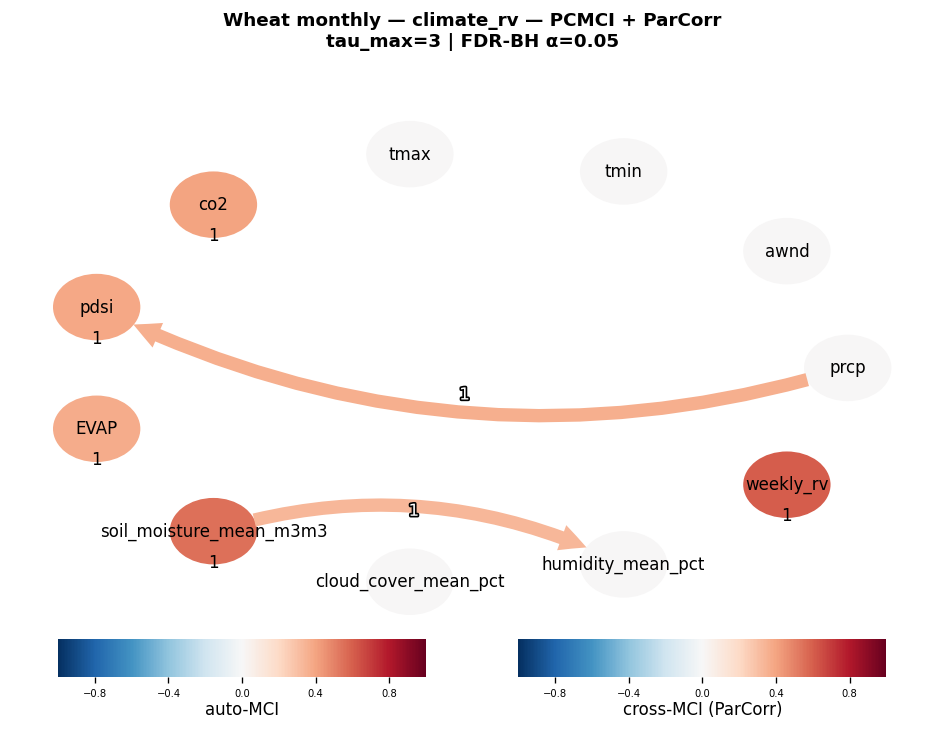

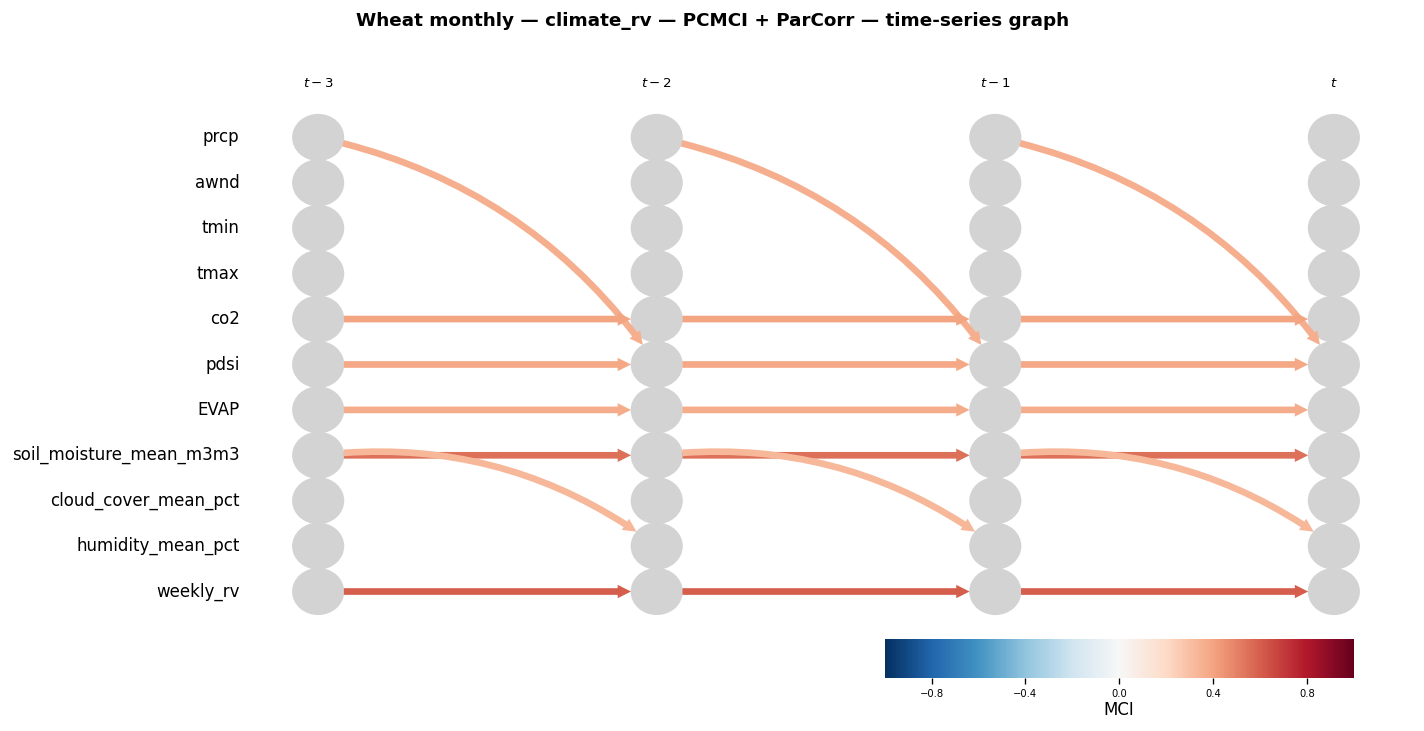


  ── macro_news_climate_rv (18 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 2 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.656
        (co2 -3): pval = 0.03819 | val =  0.321

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.697

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.744

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.492

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.641
        (Stock_Uncertainty -1): pval = 0.03259 | val = -0.331

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00000 | val =  0.456

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00000 | val =  0.499

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin ha

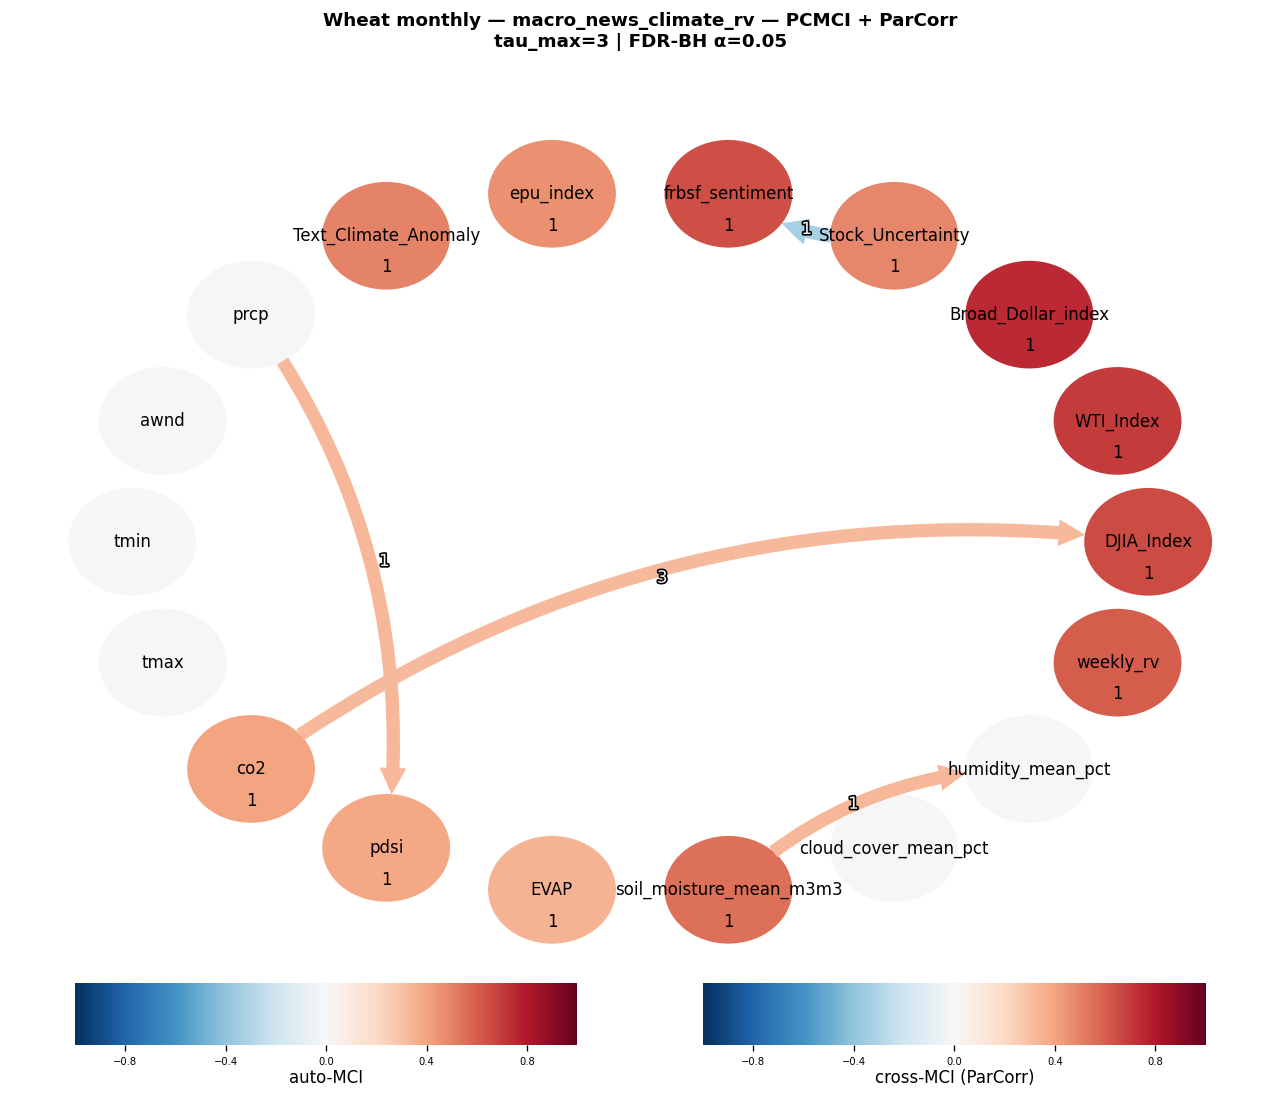

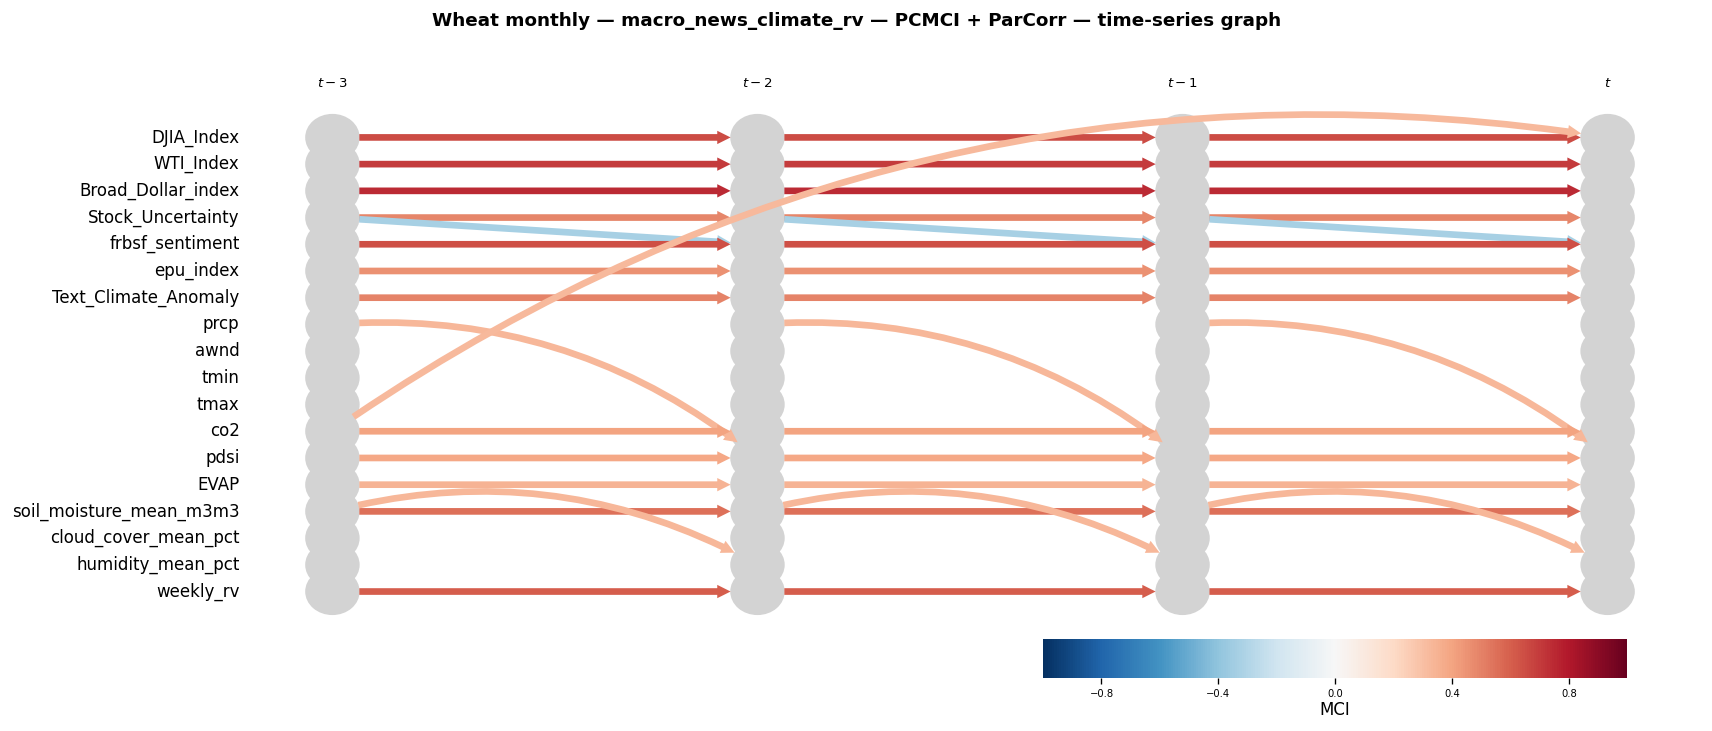


Phase 2 done.


In [23]:
# Phase 2: per-crop RV analysis — climate_rv and macro_news_climate_rv only
RV_FEATURE_SETS = {
    'climate_rv'           : ['climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

all_results: dict[str, dict] = {}

for crop in CROPS:
    print(f'\n{"#"*70}')
    print(f'  Phase 2 | {crop.upper()}  |  FREQUENCY: {FREQUENCY.upper()}')
    print(f'{"#"*70}')

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    print(f'  Preprocessed: {arr_normal.shape}  '
          f'({dates.min().date()} → {dates.max().date()})')

    all_results[crop] = {}

    for fs_name, groups in RV_FEATURE_SETS.items():
        col_names = [c for c in build_cols(groups) if c in all_cols]
        print(f'\n  ── {fs_name} ({len(col_names)} vars) ──')

        res = run_parcorr(
            feature_set_name=fs_name,
            col_names=col_names,
            arr_preprocessed=arr_normal,
            all_cols=all_cols,
            tau_max=TAU_MAX,
            pc_alpha=0.2,
            alpha_level=0.05,
            fdr_method='fdr_bh',
            max_conds_dim=None,
            verbosity=0,
        )
        all_results[crop][fs_name] = res

        res['pcmci'].print_significant_links(
            p_matrix=res['q_matrix'],
            val_matrix=res['val_matrix'],
            alpha_level=0.05,
        )
        plot_results(
            res,
            title=f'{crop.capitalize()} {FREQUENCY} — {fs_name} — PCMCI + ParCorr',
            tau_max=TAU_MAX,
        )

print('\nPhase 2 done.')

## 6. Cross-Crop Comparison: Significant Links into `weekly_rv`

Summary of what Granger-causes RV for each crop, from both per-crop feature sets.

In [24]:
for fs_name in ['climate_rv', 'macro_news_climate_rv']:
    print(f'\n{"="*65}')
    print(f'  Feature set: {fs_name}')
    print(f'{"="*65}')
    for crop in CROPS:
        links = extract_rv_links(all_results[crop][fs_name])
        print(f'\n  {crop.upper()}:')
        if links.empty:
            print('    No significant links into weekly_rv.')
        else:
            print(links.sort_values('q_val').to_string(index=False,
                  float_format='{:.3f}'.format, col_space=18))


  Feature set: climate_rv

  CORN:
             cause                lag                val              q_val
         weekly_rv                  1              0.526              0.000

  SOYBEAN:
             cause                lag                val              q_val
         weekly_rv                  1              0.618              0.000

  WHEAT:
             cause                lag                val              q_val
         weekly_rv                  1              0.603              0.000

  Feature set: macro_news_climate_rv

  CORN:
             cause                lag                val              q_val
         weekly_rv                  1              0.510              0.000

  SOYBEAN:
             cause                lag                val              q_val
         weekly_rv                  1              0.611              0.000

  WHEAT:
             cause                lag                val              q_val
         weekly_rv                  1

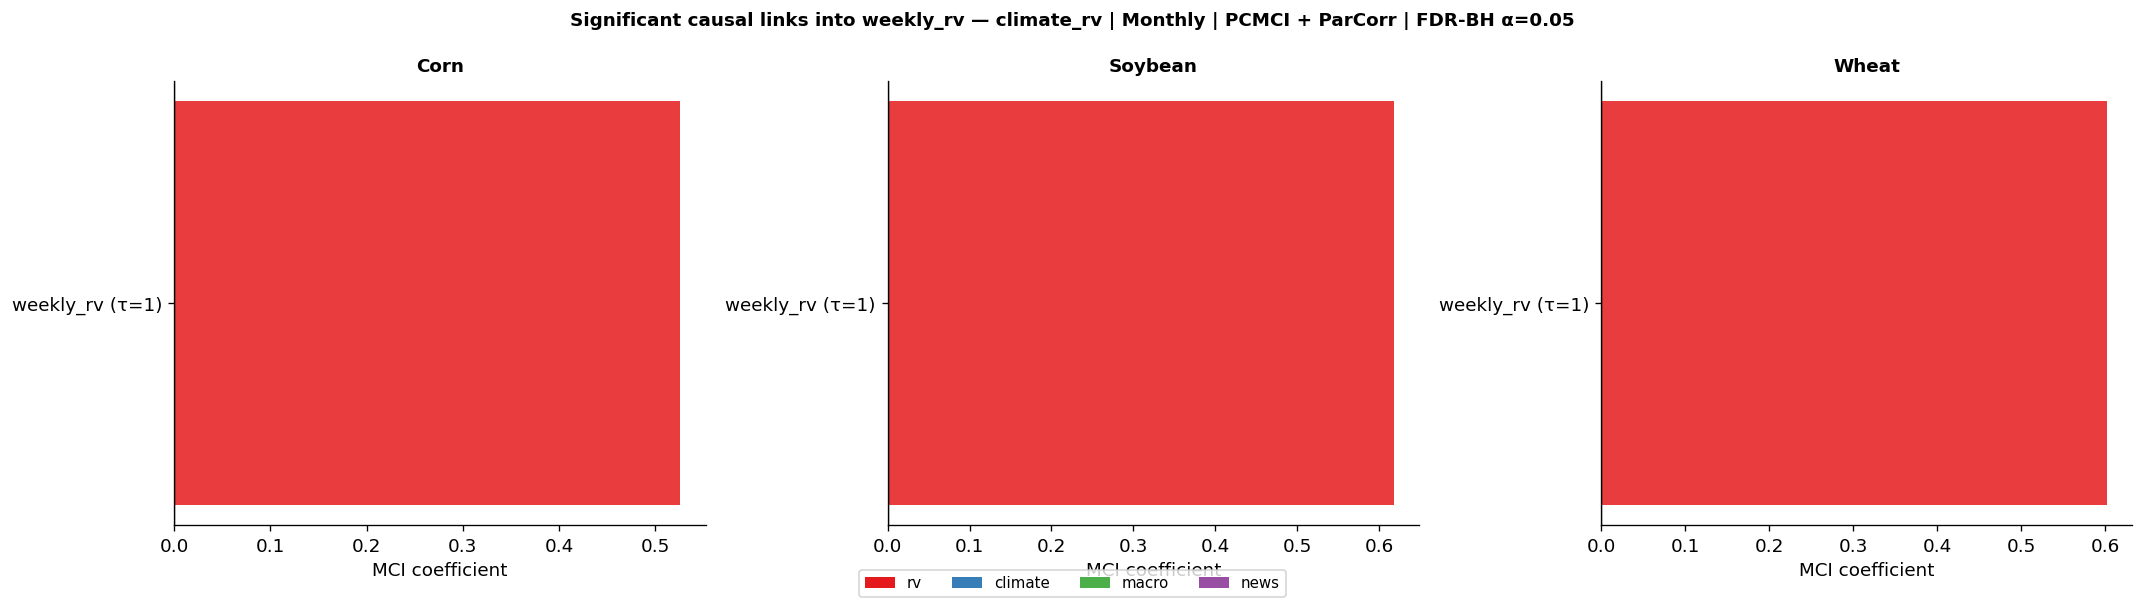

In [25]:
# ── Bar chart comparison: MCI into weekly_rv, climate_rv feature set ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, crop in zip(axes, CROPS):
    links = extract_rv_links(all_results[crop]['climate_rv'])
    if links.empty:
        ax.set_title(f'{crop.capitalize()}\n(no significant links)', fontsize=10)
        continue
    labels = [f"{r['cause']} (τ={r['lag']})" for _, r in links.iterrows()]
    vals   = links['val'].values
    colors = [GROUP_COLORS.get(group_of(r['cause']), '#888') for _, r in links.iterrows()]
    ax.barh(labels, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('MCI coefficient')
    ax.set_title(f'{crop.capitalize()}', fontsize=11, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
fig.suptitle(
    f'Significant causal links into weekly_rv — climate_rv | {FREQUENCY.capitalize()} | PCMCI + ParCorr | FDR-BH α=0.05',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

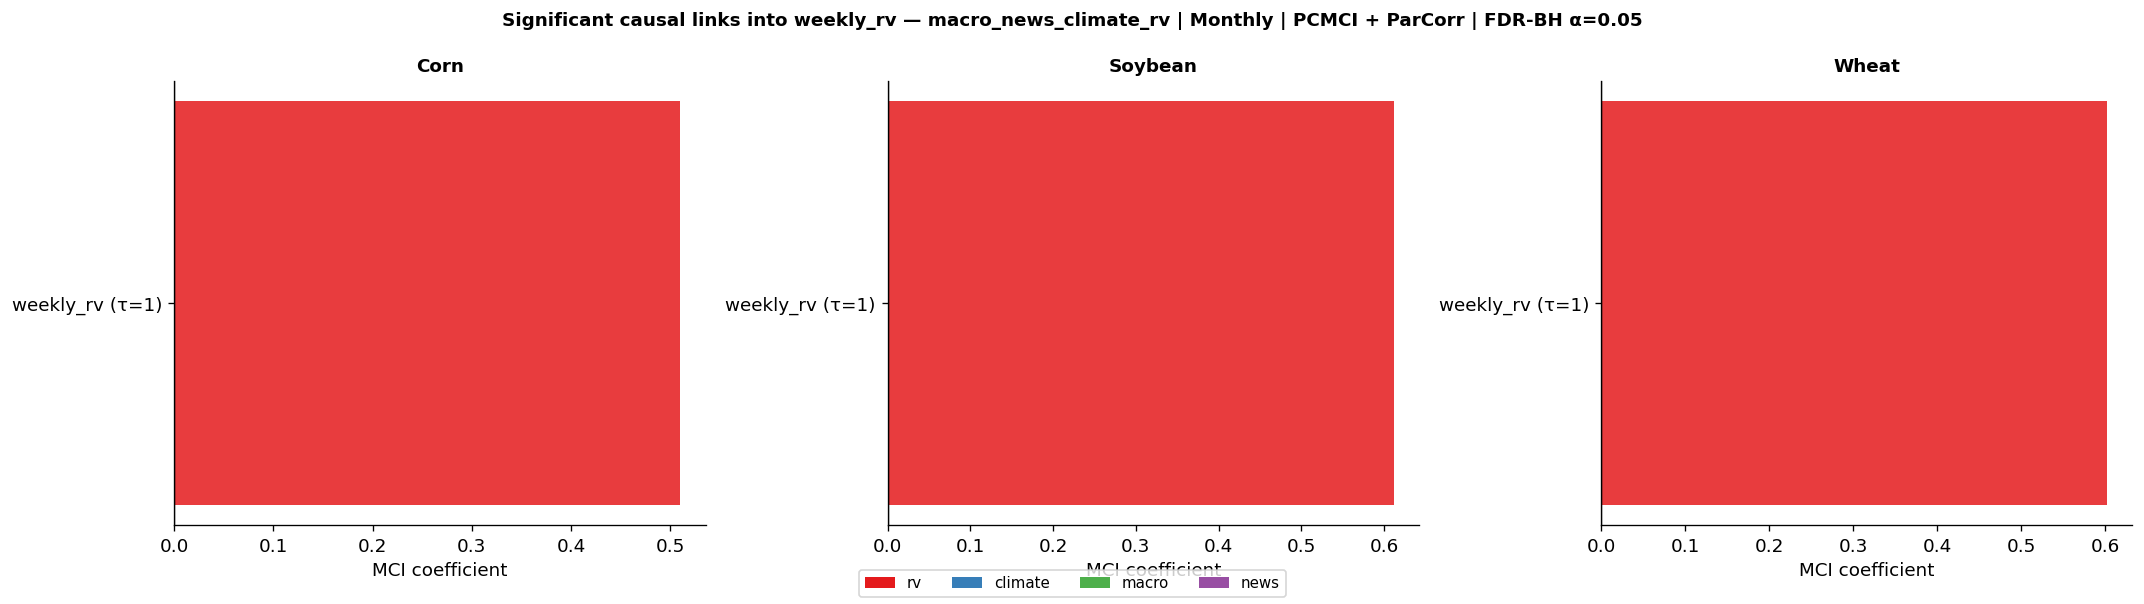

In [26]:
# ── Same chart for macro_news_climate_rv feature set ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, crop in zip(axes, CROPS):
    links = extract_rv_links(all_results[crop]['macro_news_climate_rv'])
    if links.empty:
        ax.set_title(f'{crop.capitalize()}\n(no significant links)', fontsize=10)
        continue
    labels = [f"{r['cause']} (τ={r['lag']})" for _, r in links.iterrows()]
    vals   = links['val'].values
    colors = [GROUP_COLORS.get(group_of(r['cause']), '#888') for _, r in links.iterrows()]
    ax.barh(labels, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('MCI coefficient')
    ax.set_title(f'{crop.capitalize()}', fontsize=11, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
fig.suptitle(
    f'Significant causal links into weekly_rv — macro_news_climate_rv | {FREQUENCY.capitalize()} | PCMCI + ParCorr | FDR-BH α=0.05',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 7. Summary

**Phase 1 — Climate-only (per crop):**  
Recovers the within-climate causal graph for each crop's growing region. Climate variables differ by region (prcp, awnd, tmin, tmax, pdsi), so each crop gets a distinct graph. RV excluded to study physical causal chains in isolation.

**Phase 2 — Per-crop RV analysis:**  
Only `weekly_rv` is crop-specific. Runs `climate_rv` and `macro_news_climate_rv` per crop to test Granger-causality into realized volatility.

**Preprocessing (identical to `eda_preprocessing.ipynb`):**
- Interpolate `pdsi`, `Broad_Dollar_index` | ffill `DJIA_Index`
- `pp.smooth(smooth_width=180, kernel='gaussian', residuals=True)` — 15-yr detrend
- Phase-wise anomalization (`cycle_length=12`)
- `pp.trafo2normal` — rank-based Gaussianisation

**PCMCI + ParCorr config:**
- `tau_min=1`, `tau_max=6`, `pc_alpha=0.2`
- `alpha_level=0.05`, `fdr_method='fdr_bh'`, `max_conds_dim=None`
- `significance='analytic'`

**Next steps:** cross-validate with GPDCtorch (nonlinear additive) and FAISSCMI (nonparametric).